# Кластерный анализ


### Следующий код выполняет три основных шага.
    1. Рассчитывает расстояние до ближайшего соседа между всеми событиями в каталоге.
    2. Разделяет каталог сейсмичности на семейства и независимые фоновые события на основе порогового значения ближайшего соседа.
    3. Подсчитывает количество афтершоков для каждого семейства и строит график зависимости количества афтершоков от магнитуды главного толчка.

### 0: Карта сейсмичности
Загрузка каталога сейсмичности и построение карты с помощью Basemap (этот шаг можно пропустить, если модуль базовой карты mpl не установлен)

In [133]:
# указать файл данных, время и диапазон величин
dir_in = '../data'
# этот файл создается с помощью: 1_create_mat_eqCat_file.ipynb
file_in = 'NEIC_Global_Tohoku_2011.mat'
# completeness magntiude = Mmin, and Mmax (which does not need to be specified)
Mmin, Mmax = 3, None
tmin, tmax = 1900, 2025


In [134]:
#------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import os

#------------------------------my modules-------------------------------------- 
# EqCat is a Python object that is used for catlog processing
from src.EqCat import EqCat
eqCat = EqCat()
#=================================2==============================================
#                            load data, select events
#================================================================================
eqCat.loadMatBin(f"{dir_in}/{file_in}")
print('total no. of events', eqCat.size())
eqCat.selectEvents(Mmin, Mmax, 'Mag')
eqCat.selectEvents(tmin, tmax, 'Time')
print('no. of events after Mag/Time selection', eqCat.size())

total no. of events 1926
no. of events after Mag/Time selection 1926


the following cell will only run if you have Basemap

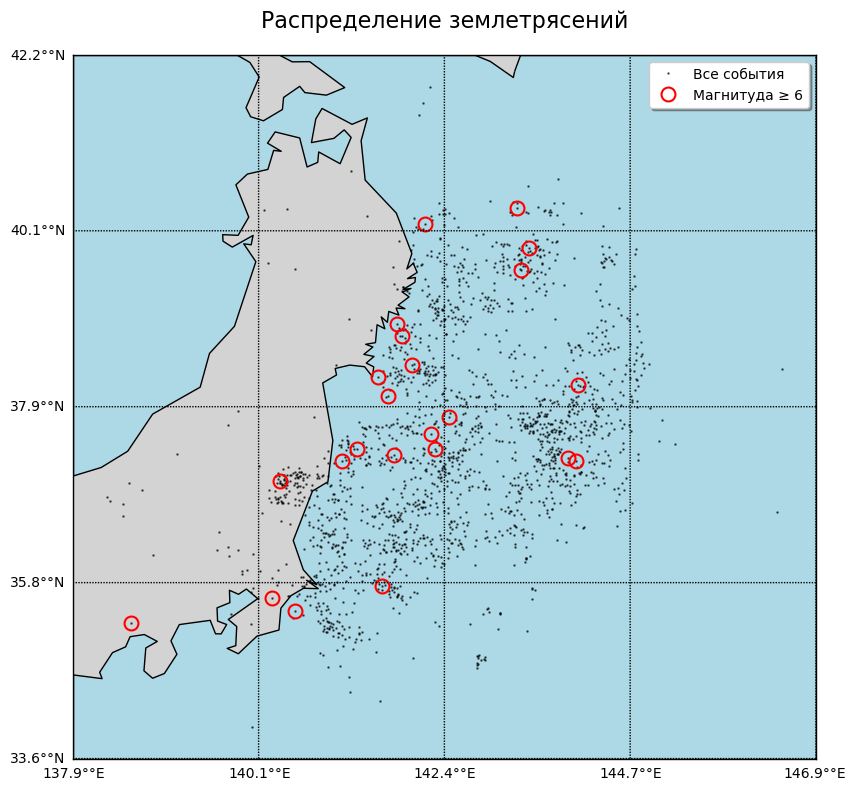

In [135]:
try:
    from mpl_toolkits.basemap import Basemap
    b_map = True
except ImportError:
    b_map = False
    print("Basemap не установлен. Установите его с помощью 'pip install basemap' или проверьте зависимости.")

# Проверяем, что Basemap доступен и данные в eqCat существуют
if b_map and hasattr(eqCat, 'data') and all(key in eqCat.data for key in ['Lon', 'Lat', 'Mag']):
    # Определяем границы карты на основе данных
    projection = 'cyl'
    xmin, xmax = eqCat.data['Lon'].min(), eqCat.data['Lon'].max()
    ymin, ymax = eqCat.data['Lat'].min(), eqCat.data['Lat'].max()

    # Добавляем отступы для лучшего отображения
    margin_x = (xmax - xmin) * 0.05
    margin_y = (ymax - ymin) * 0.05
    xmin, xmax = xmin - margin_x, xmax + margin_x
    ymin, ymax = ymin - margin_y, ymax + margin_y

    # Создаём Basemap
    m = Basemap(
        llcrnrlat=ymin, urcrnrlat=ymax,
        llcrnrlon=xmin, urcrnrlon=xmax,
        projection=projection,
        lat_0=(ymin + ymax) * 0.5,
        lon_0=(xmin + xmax) * 0.5,
        resolution='l'
    )

    # Настраиваем фигуру
    plt.figure(figsize=(12, 8))
    
    # Рисуем элементы карты
    m.drawstates(linewidth=0.5, color='gray')
    m.drawcoastlines(linewidth=1, color='black')
    m.drawcountries(linewidth=1, color='black')
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')

    # Преобразуем координаты в проекцию карты
    a_x, a_y = m(eqCat.data['Lon'], eqCat.data['Lat'])

    # Рисуем все события как тонкие чёрные точки
    m.plot(a_x, a_y, 'ko', ms=0.8, alpha=0.6, label='Все события')

    # Выделяем события с магнитудой >= 6 красными окружностями
    sel6 = eqCat.data['Mag'] >= 6
    m.plot(a_x[sel6], a_y[sel6], 'ro', ms=10, markeredgewidth=1.5, mfc='none', label='Магнитуда ≥ 6')

    # Добавляем меридианы и параллели
    meridians = np.linspace(xmin, xmax, 5)
    parallels = np.linspace(ymin, ymax, 5)
    
    m.drawmeridians(
        meridians,
        labels=[0, 0, 0, 1],
        fontsize=10,
        fmt='%.1f°'
    )
    m.drawparallels(
        parallels,
        labels=[1, 0, 0, 0],
        fontsize=10,
        fmt='%.1f°'
    )

    # Добавляем заголовок и легенду
    plt.title('Распределение землетрясений', fontsize=16, pad=20)
    plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

    # Отображаем график
    plt.tight_layout()
    plt.show()
else:
    if not b_map:
        print("Не удалось отобразить график: Basemap недоступен.")
    else:
        print("Не удалось отобразить график: данные в eqCat.data отсутствуют или неполные.")

### 1: Вычисление расстояний до ближайших соседей

Координаты переведены в декартовы с использованием эквидистантной проекции
Диапазон глубин: от 0.7  до  131.6
1 %i events with NND=0 
Сохранение файла: data/NEIC_Global_Tohoku_2011_NND_Mc_3.0.mat
Файл с eta_0 не найден: ../data/NEIC_Global_Tohoku_2011.mat_Mc_3.0_eta_0.txt — используем значение по умолчанию: -5


(-13.0, 0.0)

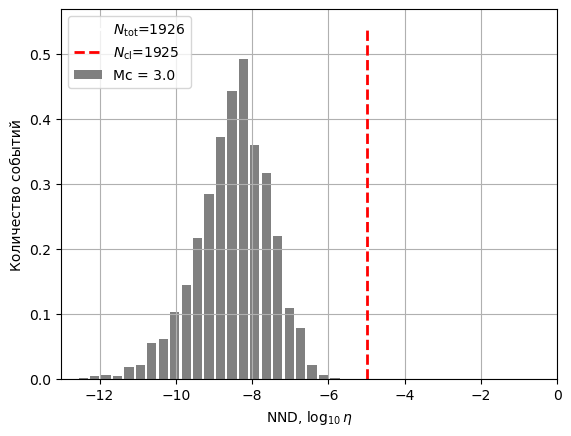

In [136]:
import src.clustering as clustering

# Установка параметров: фрактальная размерность (D) и b-значение (b)
dPar = {
    # D — фрактальная размерность пространственного распределения землетрясений
    # b — параметр закона Гутенберга-Рихтера (распределение магнитуд)
    # Эти значения должны быть определены отдельно (например, по данным)
    'D': 1.6,  # TODO: заменить на реальные значения, полученные из анализа
    'b': 1.3333398574492394,  # b-значение, лучше вычислить с помощью специального инструмента

    'Mc': Mmin,  # пороговая магнитуда (минимальная магнитуда, выше которой данные полны)

    # Параметры для построения графика
    'eta_binsize': 0.3,  # размер ячейки гистограммы по логарифмической шкале расстояний
    'xmin': -13,         # минимальное значение по оси X (логарифм расстояния)
    'xmax': 0            # максимальное значение по оси X
}

#================================================================================
#                   Перевод координат в декартовы (прямоугольные)
#================================================================================
# Есть два способа вычислить расстояния:
# 1. Спроецировать долготу и широту на плоскость (например, эквидистантная проекция),
#    затем вычислить 3D-расстояние (включая глубину).
# 2. Вычислить расстояние по поверхности Земли (по формуле гаверсинуса), 
#    а затем использовать теорему Пифагора для добавления глубины.
if b_map:
    # Если используется проекция на карту
    eqCat.toCart_coordinates(projection='eqdc')  # перевод в декартовы координаты
    print('Координаты переведены в декартовы с использованием эквидистантной проекции')

#==================================2=============================================
#        Вычисление расстояний в пространстве-времени-магнитуде (NND, ближайший сосед)
#================================================================================
# Добавляем глубину как координату Z
eqCat.data['Z'] = eqCat.data['Depth']
print('Диапазон глубин: от', eqCat.data['Z'].min(), ' до ', eqCat.data['Z'].max())

# Вычисляем расстояния до ближайшего соседа (NND) в масштабированном пространстве
# (с учётом пространства, времени и магнитуды)
# Параметры: каталог землетрясений, словарь параметров, коррекция для совпадающих событий
dNND = clustering.NND_eta(eqCat, dPar, correct_co_located=True, verbose=True)

# Построение гистограммы логарифмов расстояний до ближайшего соседа
aBins = np.arange(-13, 1, dPar['eta_binsize'], dtype=float)  # создание массива границ ячеек
aHist, aBins = np.histogram(np.log10(dNND['aNND'][dNND['aNND'] > 0]), aBins)  # гистограмма

# Центрируем ячейки (берём середину интервала)
aBins = aBins[:-1] + dPar['eta_binsize'] * 0.5

# Корректируем гистограмму на размер ячейки (чтобы получить плотность)
aHist = aHist / dPar['eta_binsize']

# Нормируем на общее количество событий → получаем оценку плотности вероятности (PDF)
aHist /= eqCat.size()

#=================================3==============================================
#                            Сохранение результатов
#================================================================================
# Сохраняем данные в формат .mat (MATLAB), удобно для последующего анализа
import scipy.io

# Имя файла: имя_входного_файла_NND_Mc_пороговая_магнитуда.mat
NND_file = f"data/{file_in.split('.')[0]}_NND_Mc_{dPar['Mc']:.1f}.mat"
print('Сохранение файла:', NND_file)

# Сохраняем словарь dNND (включая расстояния до соседей) в .mat-файл с сжатием
scipy.io.savemat(NND_file, dNND, do_compression=True)

#=================================4==============================================
#                          Построение гистограммы
#================================================================================
# Загрузка значения eta_0 (характерное расстояние, связанное с кластеризацией)
# Используется только для отображения на графике
eta_0_file = f"{dir_in}/{file_in}_Mc_{dPar['Mc']:.1f}_eta_0.txt"

if os.path.isfile(eta_0_file):
    print('Загружаем eta_0 из файла')
    f_eta_0 = np.loadtxt(eta_0_file, dtype=float)  # читаем значение eta_0
    print('eta_0 =', f_eta_0)
else:
    # Если файл не найден — используем значение по умолчанию
    f_eta_0 = -5
    print('Файл с eta_0 не найден:', eta_0_file, '— используем значение по умолчанию:', f_eta_0)

# Создаём график
fig, ax = plt.subplots()

# Строим гистограмму как столбчатую диаграмму
ax.bar(aBins, aHist,
       width=0.8 * dPar['eta_binsize'],  # ширина столбцов
       align='edge',                    # выравнивание по краю
       color='.5',                      # серый цвет
       label='Mc = %.1f' % dPar['Mc']) # подпись: пороговая магнитуда

# Вертикальная белая линия — общее количество событий (N_tot)
ax.plot([f_eta_0, f_eta_0], ax.get_ylim(), 'w-', lw=2,
        label=r'$N_\mathrm{tot}$=%i' % eqCat.size())

# Вертикальная красная пунктирная линия — количество кластерных событий (N_cl)
# (события с очень малым расстоянием до ближайшего соседа — считаются частью кластера)
ax.plot([f_eta_0, f_eta_0], ax.get_ylim(), 'r--', lw=2,
        label=r'$N_\mathrm{cl}$=%i' % dNND['aNND'][dNND['aNND'] < 1e-5].shape[0])

# Размещаем легенду в верхнем левом углу
ax.legend(loc='upper left')

# Подписи осей
ax.set_xlabel(r'NND, $\log_{10} \eta$')  # NND — расстояние до ближайшего соседа
ax.set_ylabel('Количество событий')

# Включаем сетку
ax.grid(True)

# Устанавливаем пределы по оси X
ax.set_xlim(dPar['xmin'], dPar['xmax'])

На рисунке выше показана гистограмма ближайших расстояний между исходными землетрясениями в каталоге (пространство-время-магнитуда).

Стоит обратить внимание на то, что в типичном каталоге землетрясений возникают два различных режима: кластерный режим (слева) и фоновый режим (справа). Первый режим представляет собой кластеризацию типа Омори (обычно «ближе»), а второй — фоновый пуассоновский процесс. Землетрясения в фоновом режиме — это землетрясения, которые, как можно наблюдать, не вызваны предыдущим землетрясением. $\eta_0$ — это пороговое значение между этими двумя режимами. На практике это приведёт к удалению всех связей между землетрясениями, превышающими это пороговое значение, и формированию отдельных кластеров землетрясений.

Для быстрого анализа можно просто выбрать значение, разделяющее эти режимы. Меньшие значения приведут к меньшим кластерам, большие — к более обширным кластерам, но могут включать фоновую сейсмичность.

### 2: Отделение кластеров от независимого фона и составление семейств событий

In [137]:
dPar['eta_0'] = f_eta_0
print('порог сходства', dPar['eta_0'])

порог сходства -5


In [138]:
clust_file = file_in.replace('all.mat', f'Mc_{dPar["Mc"]:.1f}_clusters.mat')
    
dNND['aNND'] = np.log10( dNND['aNND'])
# кластеризация по критериям сходства eta_0
dClust = clustering.compileClust( dNND, f_eta_0, useLargerEvents = False)
#=================================4==========================================================================
#                           сохранение результатов
#============================================================================================================
scipy.io.savemat( os.path.join( dir_in,clust_file), dClust, do_compression=True)


assuming threshold (-5) is a MAXIMUM, select similarity values BELOW this threshold
---------compileClust - initial numbers:------
No. singles: 0
No. triggered: 1925, 1925,No. tot. 1925 1925
N event IDs in more than one cluster: 0
initial singles now parents - remove from dClust['0']:  0
---------------final result--------------------------
 Ntot in cluster: 1926, N-parent(=N-clust): 1,No. singles: 0, Ntot. offspring (includes doubles):  1925
trig. fraction:  1.0 frac.MS:  0.0 single:  0.0
Ntot in cat. 1926 N-trig + N-ind 1926


### Создание тестовых графиков для проверки работоспособности.
Первый график даёт приблизительный обзор кластерных и независимых событий в области пространства-времени с изменённым масштабом.

Это обеспечивает визуализацию кластерного поведения, описанного выше. На этот раз в нормализованном пространственном расстоянии ($R_{ij}$) в сравнении с нормализованным временным расстоянием ($T_{ij}$). Где:

$$ R_{ij} = r_{ij}^d\times10^{bM_i/2} $$
$$ T_{ij} = t_{ij}\times10^{bM_i/2} $$

size of offspring catalog 1925 size of parent cat 1925
check if integral ~1 0.73


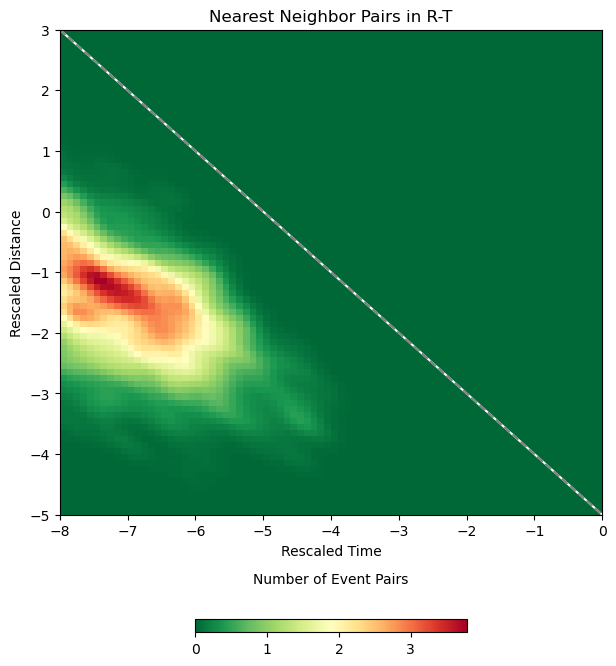

In [139]:
#=======event-pair density in r-T============================
catChild=  EqCat()
catParent= EqCat()
catChild.copy(  eqCat)
catParent.copy( eqCat)
catChild.selEventsFromID(    dNND['aEqID_c'], repeats = True)
catParent.selEventsFromID(   dNND['aEqID_p'], repeats = True)
print( 'size of offspring catalog', catChild.size(), 'size of parent cat', catParent.size())  

#compute re-scaled interevent times and distances
a_R, a_T = clustering.rescaled_t_r(catChild, catParent, dPar)
# plot event pair density 
fig = clustering.plot_R_T( a_T, a_R, f_eta_0)


1. **Оси**:
   - **X-ось (Rescaled Time)**: Масштабированное время (log10(a_T)), где `a_T` — это разница во времени между родительским и дочерним событиями, скорректированная с учётом магнитуды и параметров каталога (b-значение и фрактальная размерность D). Это отражает, насколько быстро происходят афтершоки относительно основного толчка.
   - **Y-ось (Rescaled Distance)**: Масштабированное расстояние (log10(a_R)), где `a_R` — это пространственное расстояние между событиями, также скорректированное с учётом параметров (обычно в километрах, преобразованное через фрактальную размерность).

2. **Цветовая карта (Density Plot)**:
   - График использует двумерную плотность событий (`normZZ`), вычисленную функцией `data_utils.density_2D`. Чем ярче цвет (например, зелёный или жёлтый по схеме `RdYlGn_r`), тем выше концентрация пар событий в данной области.
   - `normZZ` нормализуется на общее количество событий и размер ячеек (`binx * biny * eqCatMc.size()`), чтобы отразить количество пар событий на единицу площади.

3. **Линия разделения (eta_0)**:
   - На графике рисуются две линии:
     - Твёрдая белая линия (`'-', lw=1.5, color='w'`) и пунктирная серая линия (`'--', lw=1.5, color='.5'`) на уровне `f_eta_0` (в вашем случае -9.232).
     - Эти линии представляют границу между кластерными (ниже порога) и фоновыми (выше порога) событиями. События ниже этой линии считаются связанными (например, афтершоками), а выше — независимыми.

### Что это значит
- **Распределение кластеров**: График показывает, как пары событий группируются во времени и пространстве после масштабирования. Кластерные события (афтершоки) обычно сосредоточены в нижней левой части (близкие времена и расстояния), тогда как фоновые события распределены более равномерно.
- **Порог eta_0**: Значение -9.232 (среднее eta_0 из вашего вывода) используется для разделения. Если логарифм масштабированного времени минус логарифм масштабированного расстояния меньше -9.232, событие классифицируется как часть кластера.
- **Интерпретация плотности**: Высокая плотность (яркие области) указывает на регионы, где афтершоки наиболее вероятны (например, сразу после главного толчка на небольших расстояниях).

Теперь давайте также рассмотрим различные семьи и то, как связаны между собой отдельные события.

Text(0, 0.5, 'Latitude')

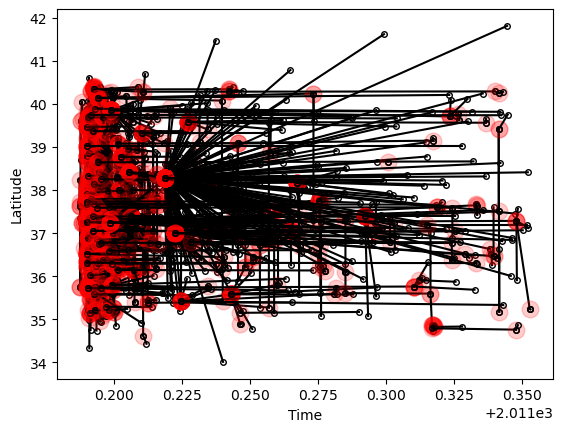

In [140]:
#==================================4=============================================
#                          spanning tree
#================================================================================
plt.figure( 1)
ax = plt.subplot(111)  
for iEv in range( catParent.size()):
    print( f"MS-ID, {int(catParent.data['N'][iEv]):d}, t-Par: {catParent.data['Time'][iEv]:.5f},'t-child', {eqCat.data['Time'][iEv]:.5f}", end= "\r")

    if dNND['aNND'][iEv] < dPar['eta_0']:#triggered cluster
        ax.plot( [catParent.data['Time'][iEv]], [catParent.data['Lat'][iEv]], 'ro', ms = 12, alpha = .2)
        ax.plot( [catParent.data['Time'][iEv],catChild.data['Time'][iEv]],
                  [catParent.data['Lat'][iEv], catChild.data['Lat'][iEv]], 'k-', marker = 'o', ms = 4, mew =1, mfc = 'none')
    else: # independent events
        ax.plot( [catChild.data['Time'][iEv]], [catChild.data['Lat'][iEv]], 'bo', ms = 5, alpha = .6)
ax.set_xlabel('Time')
ax.set_ylabel('Latitude')

Синие точки на представленном выше графике представляют собой независимые фоновые события. Это означает, что их ближайший сосед находится за пределами выбранного (или рассчитанного) значения eta_0.

Красные и чёрные круги — это кластерные события, соединённые чёрными линиями.
Чем темнее красный цвет, тем больше событий связано с этим родителем.
Чёрные круги — это последнее поколение в серии триггеров, т.е. афтершоки, которые сами по себе не вызывают афтершоков.

### 3: Подсчет афтершоков и построение графика зависимости производительности атершоков

In [141]:

#=================================1==============================================
#                            load data, select events
#================================================================================
N_tot = eqCat.size()
print(  'total no. of events', N_tot)
#=================================2==========================================================================
#                     singles are counted as MS with 0 AS
#============================================================================================================
print( 'total number of clusters', len(  dClust.keys()), 'no. of BG events', dClust['0'].shape[0])
a_ID_single  = dClust['0']

# IDs of BG events
a_iSel       = np.zeros( eqCat.size(), dtype = int)
a_mag_single = np.zeros( len( a_ID_single))
a_N_AS_single= np.zeros( len( a_ID_single))
a_N_FS_single= np.zeros( len( a_ID_single))
for i in range( a_ID_single.shape[0]):
    # event ID may be in catalog more than once
    sel_ev          = eqCat.data['N'] == a_ID_single[i]
    a_mag_single[i] = eqCat.data['Mag'][sel_ev][0]
    a_iSel[sel_ev] = 1 # catalog.data['N'][catalog.data['N']==aEqID[i]][0]
    if sel_ev.sum() != 1:
        error_str = 'more than event found', eqCat.data['N'][sel_ev]
        raise( ValueError( error_str))
### remove singles from catalog
eqCat.selDicAll( np.logical_not(a_iSel))
print( 'remaining events', eqCat.size(), 'BG events', len( a_mag_single))
dClust.pop('0') # remove singles

total no. of events 1926
total number of clusters 2 no. of BG events 0
remaining events 1926 BG events 0


array([], dtype=float64)

In [142]:

#=================================2==========================================================================
#                   get MAGs of MS with aftershocks, count aftershocks
#============================================================================================================
a_N_FS    = np.zeros( len( dClust.keys()), dtype = int)
a_N_AS    = np.zeros( len( dClust.keys()), dtype = int)
a_MS_mag  = np.zeros( len( dClust.keys()))
a_MS_ID   = np.zeros( len( dClust.keys()), dtype = int)
iCl = 0
for sCl in dClust.keys():
    aEqID = dClust[sCl]# np.unique( dClust[sCl].flatten()) unique is not needed anymore, createCluster has been fixed
    print( 'cl: ', iCl+1,'out of: ', len( dClust.keys()), 'no. of ev. in cl.', 
          len( aEqID), len( np.unique( dClust[sCl])), end="\r")
    # find MS mag and magnitude of entire family
    atmp_MAG = np.zeros( len( aEqID))
    atmp_Time= np.zeros( len( aEqID))
    a_iSel   = np.zeros( eqCat.size(), dtype = int)
    # for each family find: event mag. and origin time
    for iM in range( len( aEqID)):
        sel_ev        = eqCat.data['N'] == aEqID[iM]
        if sel_ev.sum() != 1:
            error_str = 'more/less than event found', eqCat.data['N'][sel_ev], aEqID[iM]
            raise(  ValueError, error_str)
        atmp_MAG[iM]  = eqCat.data['Mag'][sel_ev][0]
        atmp_Time[iM] = eqCat.data['Time'][sel_ev][0]
        a_iSel[sel_ev] = 1
    # remove events from catalog
    #catalog.selDicAll( np.logical_not(a_iSel))
    #----------------------------mainshock-------------------------------------------------- 
    selMS     = atmp_MAG == atmp_MAG.max()
    f_tMS     = atmp_Time[selMS][0]
    i_ID_MS   = aEqID[selMS]

    #print( 'tMS', tMS, v_currEqID.shape[0], 'MAG', curr_cat.data['MAG'][selMS][0]
    #----------------------------aftershock-------------------------------------------------- 
    selAS     = atmp_Time > f_tMS
    selFS     = atmp_Time < f_tMS
    #print( 'no. of aftershocks', selAS.sum()
    # save number of aftershocks for each MS mag
    a_MS_mag[iCl] = atmp_MAG[selMS][0]#, dPar['magRound'])
    a_N_AS[iCl]   = selAS.sum()
    a_N_FS[iCl]   = selFS.sum()
    a_MS_ID[iCl]  = int( i_ID_MS[0])
    iCl += 1

#=================================3==========================================================================
#                  compare MS+single+FS+AS to original number of events in catalog
#============================================================================================================
# combine single without AS with mainshocks that do have aftershocks
a_N_FS    = np.append( a_N_FS, a_N_FS_single)
a_N_AS    = np.append( a_N_AS, a_N_AS_single)
a_MS_mag  = np.append( a_MS_mag, a_mag_single)
a_MS_ID   = np.append( a_MS_ID, a_ID_single)
print( 'tot ev. in catalog', N_tot,'tot events in families',a_N_FS.sum() + a_N_AS.sum() + a_MS_mag.shape[0])
#print( 'N BG', a_mag_single.shape[0], 'FS', a_N_FS_single.sum(), 'AS', a_N_AS_single.sum(), 'MS (MS+BG)', a_MS_mag.shape[0]

#=================================4==========================================================================
#                    save to ASCII text
#============================================================================================================
file_out = '%s/%s_Nas_MS_Mc_%.1f.txt'%(dir_in, file_in.split('.')[0], dPar['Mc'])#, dPar['magRound'])
m_N_as   = np.array([a_MS_mag, a_N_AS, a_N_FS, a_MS_ID])
np.savetxt( file_out, m_N_as.T, fmt='%10.3f%10i%10i%14i',
            header = 'MAG          N-AS          N-FS        MS-ID; note N_AS=0 highlights singles or FS only')


tot ev. in catalog 1926 tot events in families 1926.0


the two numbers above should hopefully match, otherwise you may have to rerun the code from the beginning

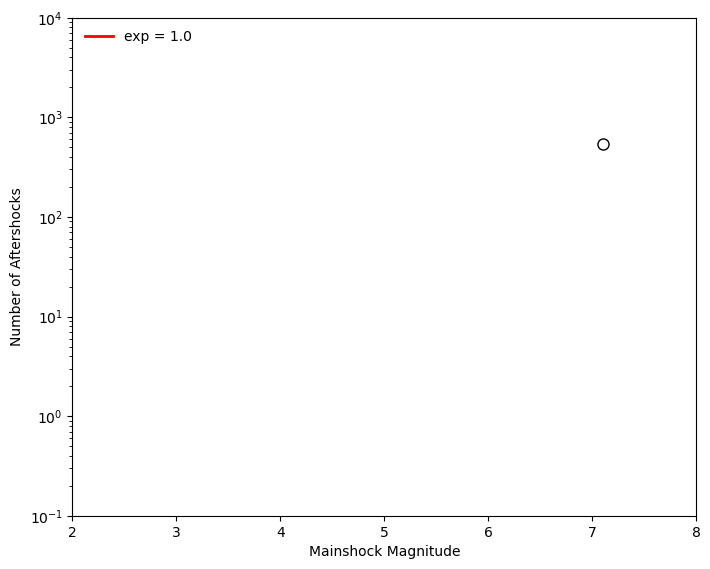

In [143]:
dPar['magRound'] = 1 # binning
#=================plotting==============
dPar['alpha']    =  1.0 # power law exponent
dPar['xmin']     =  2  
dPar['xmax']     =  8
dPar['ymin']     = 0.1  
dPar['ymax']     = 1e4

#=================================2==========================================================================
#                           count ave. no. of aftershocks per MS magnitude
#============================================================================================================
aMag_round= np.around( m_N_as[0], dPar['magRound'])
aMag_bin  = np.array( sorted(np.unique( aMag_round)))
aAveNo_AS = np.ones( len( aMag_bin))*np.nan
aNo_Fam   = np.zeros( len( aMag_bin)) # total number of families within mag bin
aNo_AS20  = np.zeros( len( aMag_bin))
aNo_AS80  = np.zeros( len( aMag_bin))

i = 0
for curr_mag in aMag_bin:
    selMag       = curr_mag == aMag_round
    aAveNo_AS[i] = m_N_as[1][selMag].mean()
    if selMag.sum() > 0:
        aNo_AS20[i]  = np.percentile( m_N_as[1][selMag], 20)
        aNo_AS80[i]  = np.percentile( m_N_as[1][selMag], 80)
    aNo_Fam[i]   = selMag.sum()
    print( curr_mag, 'mean N-AS', round(aAveNo_AS[i],2),  aNo_AS20[i],aNo_AS80[i], 'no. of fam', aNo_Fam[i],end="\r")

    i += 1

#=================================3==========================================================================
#                           plot productivity law
#============================================================================================================
plt.figure(1, figsize=(8,6))
ax = plt.axes([.14,.12,.78,.83])#pPlot.createFigureSquare(1)
ax.semilogy( m_N_as[0],   m_N_as[1],     'o',  ms = 6, mew =0, mfc = '.7', alpha = .2 )
yerr_low = np.maximum(0, aAveNo_AS - aNo_AS20)
yerr_high = np.maximum(0, aNo_AS80 - aAveNo_AS)
#ax.errorbar( aMag_bin,  aAveNo_AS, yerr=[np.zeros(aMag_bin.shape[0]), aNo_AS80-aAveNo_AS],
#             fmt = 'o', ecolor = 'k', elinewidth=.7,capsize=2.5, mec = 'k', ms = 8, mew = 1, mfc = 'w')
#ax.errorbar( aMag_bin,  aAveNo_AS, yerr=[aAveNo_AS-aNo_AS20, aNo_AS80-aAveNo_AS],
#             fmt = 'o', ecolor = 'k', elinewidth=.7,capsize=2.5, mec = 'k', ms = 8, mew = 1, mfc = 'w')
ax.errorbar(aMag_bin, aAveNo_AS, yerr=[yerr_low, yerr_high],
            fmt='o', ecolor='k', elinewidth=.7, capsize=2.5, mec='k', ms=8, mew=1, mfc='w')

#-------------------------exponential - estimate-----------------------------------------------------
mag_fit    = aMag_bin[min(4, len(aMag_bin)-1)] # force fit through this point
f_no_AS_pl = aAveNo_AS[aMag_bin == mag_fit]
preFac     = np.log10( f_no_AS_pl) - dPar['alpha']*mag_fit
a_N_hat    = 10**( dPar['alpha']*aMag_bin + preFac)
ax.semilogy( aMag_bin, a_N_hat, 'w-')
ax.semilogy( aMag_bin, a_N_hat, '-', color = 'r', lw = 2, label = 'exp = %.1f'%( np.round( dPar['alpha'],1)))

#-------------------------------labels, limits etc.-----------------------------------------------
ax.set_xlim( dPar['xmin'], dPar['xmax'])
ax.set_ylim( dPar['ymin'], dPar['ymax'])
ax.set_xlabel( 'Mainshock Magnitude')
ax.set_ylabel( 'Number of Aftershocks')
ax.legend( loc = 'upper left', frameon = False);


In [144]:
#=================================4==========================================================================
#                           Визуализация кластеров на географической карте
#============================================================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    print("Ошибка: Cartopy не установлен. Установите его с помощью 'pip install cartopy' или 'conda install cartopy'.")
    raise

# Предполагается, что dNND — результат функции NND_eta, а dClust — результат separateFamilies
# Если они не определены, нужно выполнить NND_eta и separateFamilies
# Пример:
# from clustering import NND_eta, separateFamilies
# dConst = {'Mc': Mmin, 'b': 1.0, 'D': 1.6}
# dNND = NND_eta(eqCat, dConst, verbose=True)
# dClust = separateFamilies(dNND, eta_0=-4.5)

# Проверяем наличие dNND
try:
    dNND
except NameError:
    print("Ошибка: dNND не определен. Выполните NND_eta перед визуализацией.")
    raise

# Синхронизируем dNND с текущим каталогом
if len(dNND['aNND']) != len(eqCat.data['Lon']):
    print(f"Ошибка: Размер dNND['aNND'] ({len(dNND['aNND'])}) не соответствует размеру каталога ({len(eqCat.data['Lon'])}).")
    print("Синхронизируем dNND с текущим каталогом...")
    sel_valid = np.in1d(dNND['aEqID_c'], eqCat.data['N'])
    dNND = {
        'aNND': dNND['aNND'][sel_valid],
        'aEqID_p': dNND['aEqID_p'][sel_valid],
        'aEqID_c': dNND['aEqID_c'][sel_valid],
        'Time': dNND['Time'][sel_valid]
    }

# Проверяем, что размеры совпадают
if len(dNND['aNND']) != len(eqCat.data['Lon']):
    print(f"Ошибка: После синхронизации размер dNND['aNND'] ({len(dNND['aNND'])}) все еще не соответствует размеру каталога ({len(eqCat.data['Lon'])}).")
    raise IndexError("Несоответствие размеров данных.")

# Определяем sel_clust: события с log10(aNND) < eta_0 считаются кластеризованными
eta_0 = -4.5  # Настройте порог на основе анализа (например, из plot_R_T)
sel_clust = np.log10(dNND['aNND']) < eta_0  # Булев массив для кластеризованных событий

# Проверяем наличие dClust
try:
    dClust
except NameError:
    print("Ошибка: dClust не определен. Убедитесь, что separateFamilies выполнена.")
    raise

# Синхронизируем dClust с текущим каталогом
for famID in list(dClust.keys()):
    indices = dClust[famID]
    valid_indices = np.in1d(indices, eqCat.data['N'])
    dClust[famID] = indices[valid_indices]
    if len(dClust[famID]) == 0:
        print(f"Предупреждение: Кластер {famID} пуст после синхронизации. Удаляем его.")
        del dClust[famID]

num_clusters = len(dClust)
if num_clusters == 0:
    print("Предупреждение: Нет кластеров для отображения после синхронизации.")

# Создаем фигуру с географической проекцией
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())  # Простая географическая проекция

# Добавляем географические элементы
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle='--', edgecolor='gray')

# Устанавливаем границы карты
lon_min, lon_max = eqCat.data['Lon'].min() - 1, eqCat.data['Lon'].max() + 1
lat_min, lat_max = eqCat.data['Lat'].min() - 1, eqCat.data['Lat'].max() + 1
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Рисуем фоновые события (не кластеризованные) серым цветом
sel_bgr = ~sel_clust
ax.scatter(eqCat.data['Lon'][sel_bgr], eqCat.data['Lat'][sel_bgr],
           s=10**(eqCat.data['Mag'][sel_bgr]/2),  # Размер маркера зависит от магнитуды
           c='gray', alpha=0.5, label='Фоновые события', transform=ccrs.PlateCarree())

# Генерируем цвета для кластеров
colors = plt.cm.tab20(np.linspace(0, 1, max(num_clusters, 1)))  # Используем tab20 для разных цветов

# Рисуем каждый кластер уникальным цветом
for i, (famID, indices) in enumerate(dClust.items()):
    if len(indices) > 0:
        sel_indices = np.in1d(eqCat.data['N'], indices)
        ax.scatter(eqCat.data['Lon'][sel_indices], eqCat.data['Lat'][sel_indices],
                   s=10**(eqCat.data['Mag'][sel_indices]/2),  # Размер маркера зависит от магнитуды
                   c=[colors[i]], alpha=0.8, label=f'Кластер {famID} (Размер: {len(indices)})',
                   transform=ccrs.PlateCarree())

# Устанавливаем подписи
ax.set_title('Пространственное распределение кластеров землетрясений')

# Добавляем сетку
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Легенда
if num_clusters <= 20:
    ax.legend(loc='upper right', fontsize=8, ncol=2)
else:
    print("Слишком много кластеров для отображения легенды. Пропускаем легенду.")

plt.show()

Ошибка: Размер dNND['aNND'] (1925) не соответствует размеру каталога (1926).
Синхронизируем dNND с текущим каталогом...
Ошибка: После синхронизации размер dNND['aNND'] (1925) все еще не соответствует размеру каталога (1926).


C:\Users\seeker\AppData\Local\Temp\ipykernel_17280\418852640.py:33: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  sel_valid = np.in1d(dNND['aEqID_c'], eqCat.data['N'])


IndexError: Несоответствие размеров данных.